In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator
import re
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

In [20]:
DATA = Path("../Data")

cameras = pd.DataFrame(
    {
        "Site": [
            "Boquillas", "CharlestonMesquite", "Contention", "Fairbank",
            "Hereford", "Hunter", "Moson", "St.David",
        ],
        "Camera": [8, 2, 6, 1, 5, 4, 3, 7],
    }
)

groundwater = (
    pd.read_csv(DATA / "GW" / "C4GW.csv", parse_dates=["date"])
    .query("camera == 4")
    [["date", "dtgw"]]
    .assign(dtgw=lambda data: data["dtgw"] * 0.3048)
)

points = pd.read_csv(DATA / "pts_for_Jawad.csv").iloc[:8].copy()
points["Site"] = points["Name"].str.replace(" Camera", "", regex=False)
et = pd.concat(
    [
        pd.read_csv(DATA / "Jawad_ET" / f"J{index}.csv").assign(Site=site)
        for index, site in enumerate(points["Site"], start=1)
    ],
    ignore_index=True,
)
et["date"] = pd.to_datetime(et["date"])
et["ET"] = et["LE_model"] * 0.0353
et = et.merge(cameras, on="Site", validate="many_to_one")
et = et.query("Camera == 4")[["date", "ET"]]

flow = pd.read_csv(
    DATA / "USPPFlowMonitoring2006_2025.csv", parse_dates=["Date"]
).rename(columns={"Date": "date"})
flow["fp"] = np.select(
    [flow["Flow Code"].eq(0), flow["Flow Code"].isin([1, 2])],
    [0, 1],
    default=np.nan,
)
flow_persistence = (
    flow.loc[flow["Site"].eq("Hunter"), ["date", "fp"]]
    .dropna(subset=["fp"])
)

def water_year(dates):
    return dates.dt.year + (dates.dt.month >= 10).astype(int)

rng = np.random.default_rng(42)

def annual_metric_with_ci(data, value, statistic, n_boot=2000):
    """Return water-year estimates with percentile bootstrap 95% intervals."""
    rows = []
    grouped = data.assign(Water_Year=water_year(data["date"])).groupby("Water_Year")
    for year, group in grouped:
        values = group[value].dropna().to_numpy()
        estimates = statistic(
            rng.choice(values, size=(n_boot, len(values)), replace=True), axis=1
        )
        rows.append(
            {
                "Water_Year": year,
                value: statistic(values),
                "lo": np.quantile(estimates, 0.025),
                "hi": np.quantile(estimates, 0.975),
            }
        )
    return pd.DataFrame(rows)

def annualized_et_with_ci(data, n_boot=2000):
    """Fill unobserved days with the observed water-year mean daily ET."""
    rows = []
    grouped = data.assign(Water_Year=water_year(data["date"])).groupby("Water_Year")
    for year, group in grouped:
        values = group["ET"].dropna().to_numpy()
        days_in_year = 366 if pd.Timestamp(f"{year}-12-31").is_leap_year else 365
        estimates = rng.choice(
            values, size=(n_boot, len(values)), replace=True
        ).mean(axis=1) * days_in_year
        rows.append(
            {
                "Water_Year": year,
                "ET": values.mean() * days_in_year,
                "days_observed": len(values),
                "days_in_year": days_in_year,
                "lo": np.quantile(estimates, 0.025),
                "hi": np.quantile(estimates, 0.975),
            }
        )
    return pd.DataFrame(rows)

annual_groundwater = annual_metric_with_ci(groundwater, "dtgw", np.max)
annual_et = annualized_et_with_ci(et)
annual_et = annual_et.loc[
    annual_et["Water_Year"] < annual_et["Water_Year"].max()
].copy()

annual_flow_persistence = (
    flow_persistence.assign(Water_Year=water_year(flow_persistence["date"]))
    .groupby("Water_Year", as_index=False)["fp"]
    .agg(mean="mean", n="size")
)
annual_flow_persistence["se"] = np.sqrt(
    annual_flow_persistence["mean"] * (1 - annual_flow_persistence["mean"])
    / annual_flow_persistence["n"]
)
annual_flow_persistence["lo"] = (
    annual_flow_persistence["mean"] - 1.96 * annual_flow_persistence["se"]
).clip(lower=0)
annual_flow_persistence["hi"] = (
    annual_flow_persistence["mean"] + 1.96 * annual_flow_persistence["se"]
).clip(upper=1)

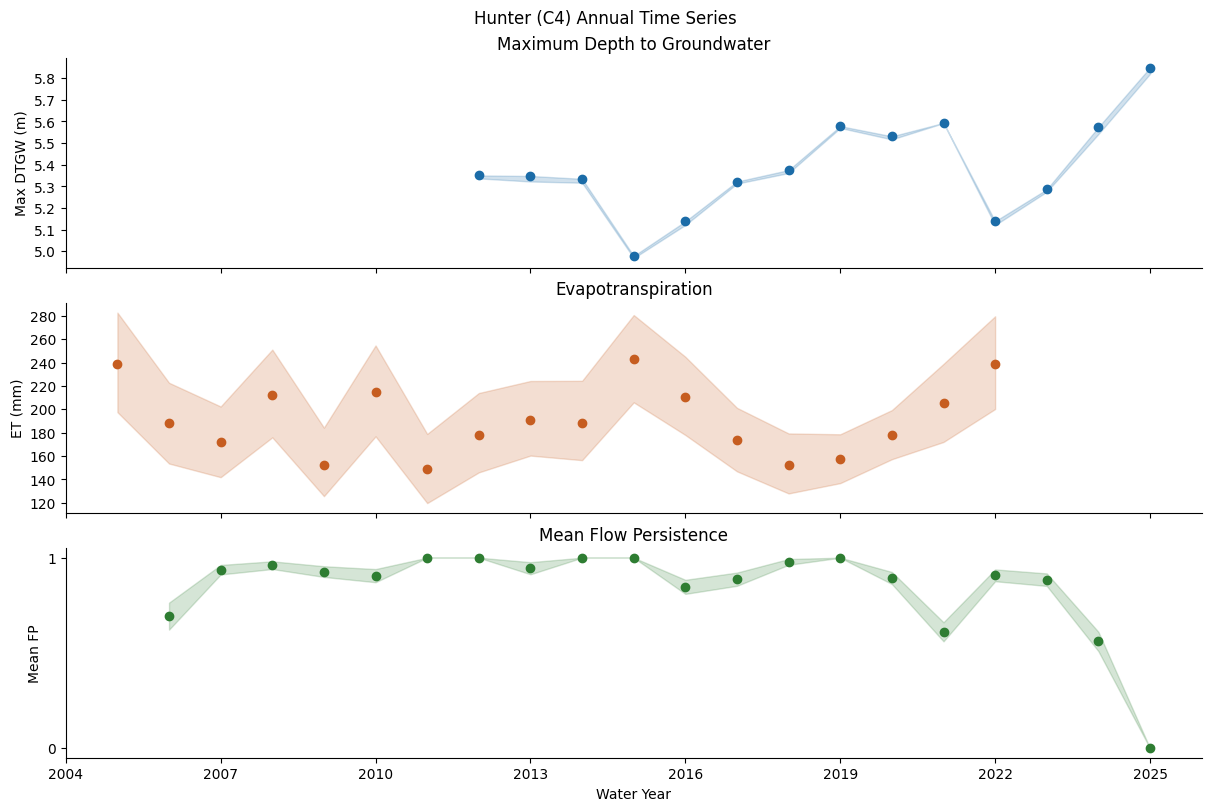

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, layout="constrained")
fig.suptitle("Hunter (C4) Annual Time Series")

axes[0].fill_between(
    annual_groundwater["Water_Year"],
    annual_groundwater["lo"],
    annual_groundwater["hi"],
    color="#1B6CA8",
    alpha=0.2,
)
axes[0].scatter(
    annual_groundwater["Water_Year"],
    annual_groundwater["dtgw"],
    color="#1B6CA8",
    zorder=2,
)
axes[0].set_title("Maximum Depth to Groundwater")
axes[0].set_ylabel("Max DTGW (m)")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[1].fill_between(
    annual_et["Water_Year"],
    annual_et["lo"],
    annual_et["hi"],
    color="#C65D20",
    alpha=0.2,
)
axes[1].scatter(
    annual_et["Water_Year"],
    annual_et["ET"],
    color="#C65D20",
    zorder=2,
)
axes[1].set_title("Evapotranspiration")
axes[1].set_ylabel("ET (mm)")
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

axes[2].fill_between(
    annual_flow_persistence["Water_Year"],
    annual_flow_persistence["lo"],
    annual_flow_persistence["hi"],
    color="#2E7D32",
    alpha=0.2,
)
axes[2].scatter(
    annual_flow_persistence["Water_Year"],
    annual_flow_persistence["mean"],
    color="#2E7D32",
    zorder=2,
)
axes[2].set_title("Mean Flow Persistence")
axes[2].set_ylabel("Mean FP")
axes[2].set_yticks([0, 1], ["0", "1"])
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_xlabel("Water Year")

for axis in axes:
    axis.spines[["top", "right"]].set_visible(False)
    axis.xaxis.set_major_locator(MaxNLocator(integer=True))

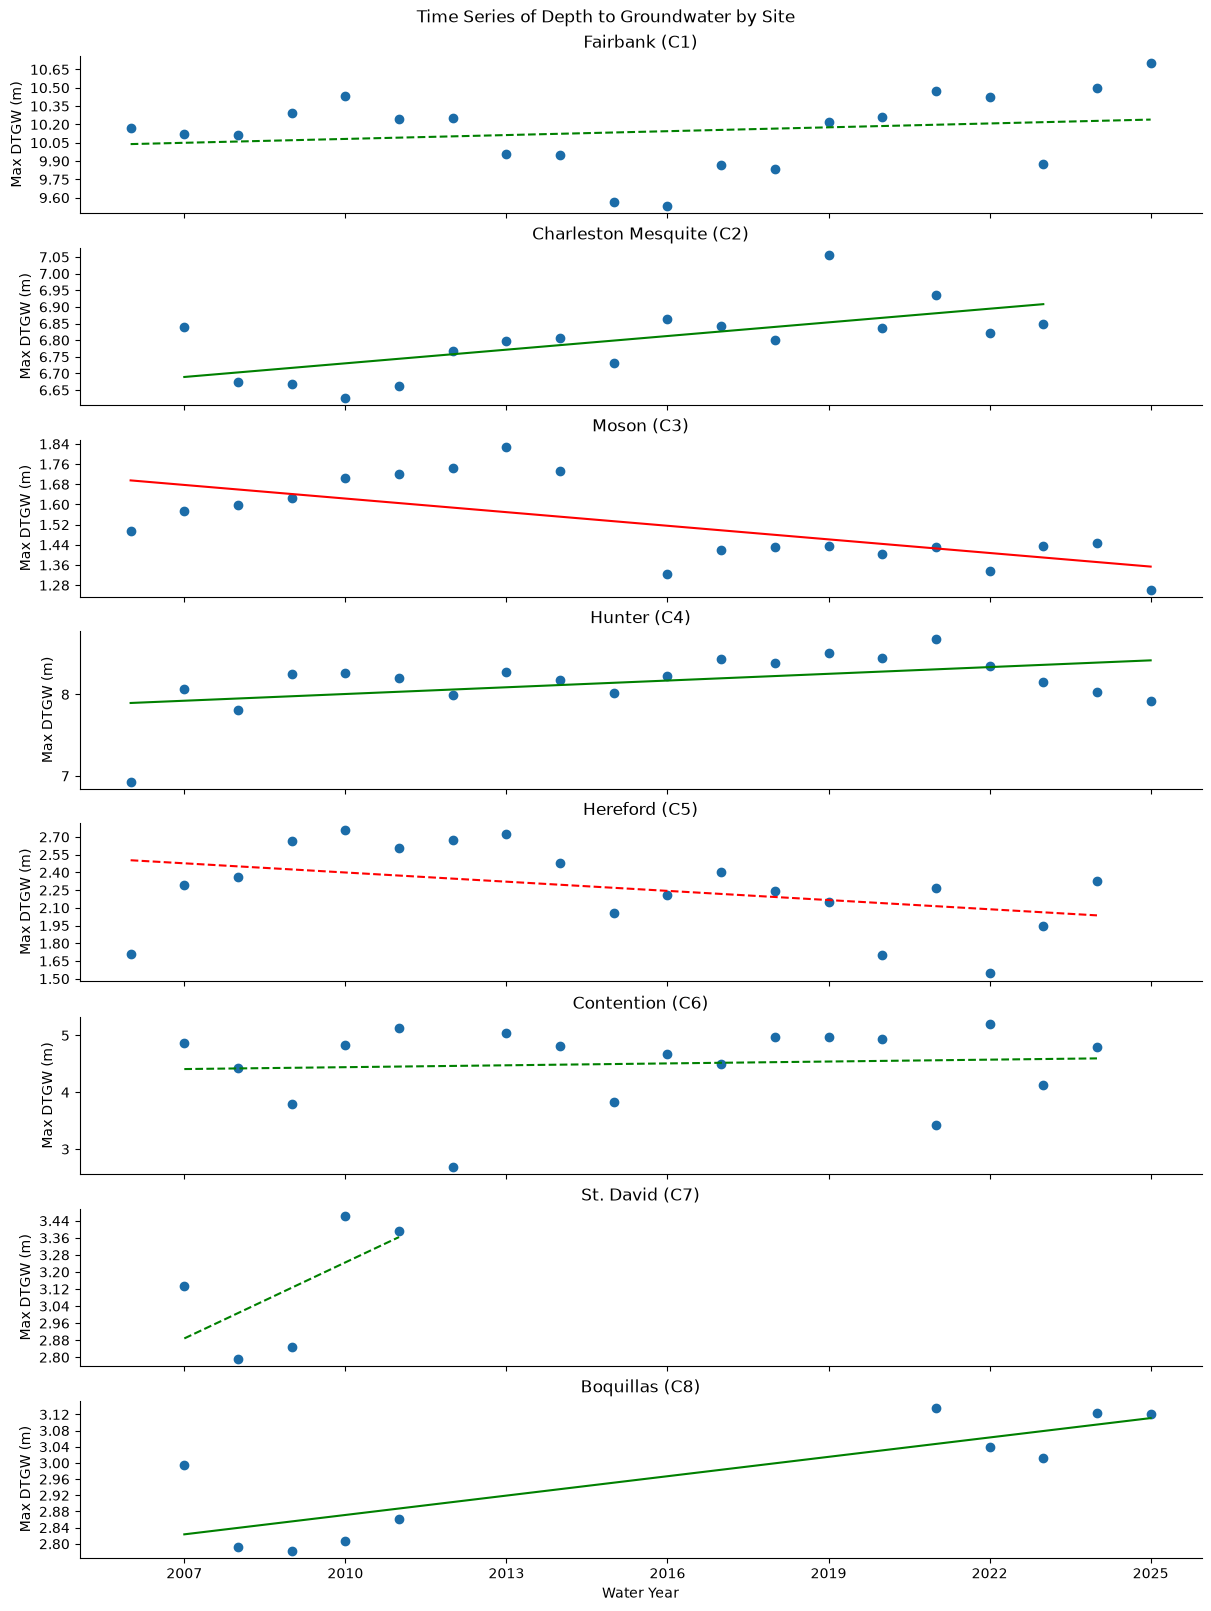

In [ ]:
camera_best_well = {
    1: "D-20-21 10AAC2 [FBK-UP]",
    2: "D-20-21 15DDB [BOQ-UP]",
    3: "D-21-21 13BAB1 [MOSLNS]",
    4: "D-22-22 33BBC [HUN-UP]",
    5: "D-23-22 04DCD4 [HERUED]",
    6: "D-19-21 28ACD [TOM-LI]",
    7: "D-19-21 05AAA1 [STD-LI]",
    8: "D-20-21 15DBD1 [BOQ-LI]",
}
shallow_gw = (
    pd.read_csv(DATA / "GW" / "ShallowGW2006_2025.csv")
    .query("site_tp_cd == 'GW' and parameter_cd == 72019")
    .assign(lev_timestamp=lambda data: pd.to_datetime(data["lev_timestamp"]))
    .sort_values("lev_timestamp")
)
shallow_gw["dtgw"] = shallow_gw["lev_va"] * 0.3048

fig, axes = plt.subplots(
    len(camera_best_well), 1, figsize=(12, 16), sharex=True, layout="constrained"
)
fig.suptitle("Time Series of Depth to Groundwater by Site")

for axis, camera in zip(axes, sorted(camera_best_well)):
    site = re.sub(r"(?<!^)(?=[A-Z])", " ", cameras.loc[cameras["Camera"] == camera, "Site"].iloc[0])
    well = camera_best_well[camera]
    series = (
        shallow_gw.loc[shallow_gw["station_nm"] == well, ["lev_timestamp", "dtgw"]]
        .rename(columns={"lev_timestamp": "date"})
    )
    annual = annual_metric_with_ci(series, "dtgw", np.max)
    regression = stats.linregress(annual["Water_Year"], annual["dtgw"])
    line_color = "green" if regression.slope > 0 else "red"
    line_style = "-" if regression.pvalue < 0.05 else "--"
    axis.scatter(annual["Water_Year"], annual["dtgw"], color="#1B6CA8", zorder=2)
    axis.plot(
        annual["Water_Year"],
        regression.slope * annual["Water_Year"] + regression.intercept,
        color=line_color,
        linestyle=line_style,
    )
    axis.set_title(f"{site} (C{camera})")
    axis.set_ylabel("Max DTGW (m)")
    axis.yaxis.set_major_locator(MaxNLocator(integer=True))
    axis.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Water Year")
axes[-1].xaxis.set_major_locator(MaxNLocator(integer=True))


C:\Users\tiffa\AppData\Local\Temp\ipykernel_18848\3612394152.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_june.legend(frameon=False, loc="upper left")


Text(0.99, 0.03, 'r = 0.27')

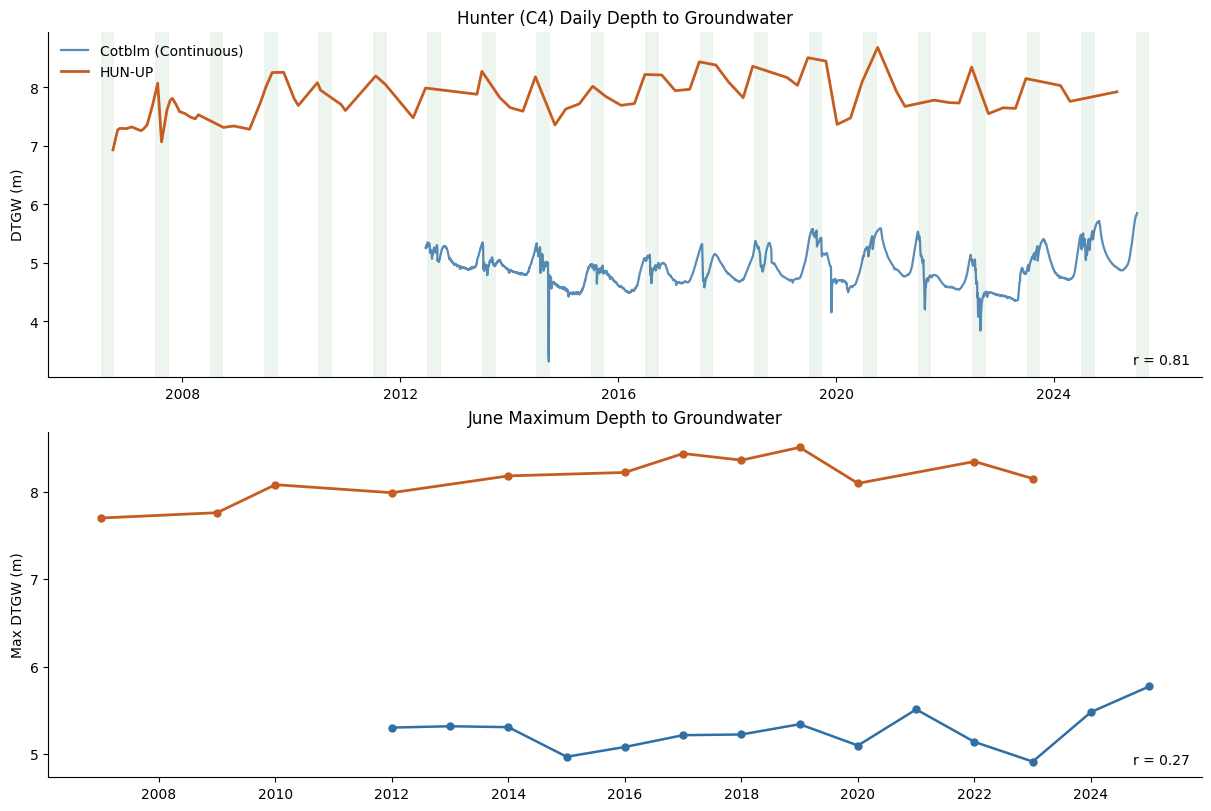

In [24]:
hunter_well = "D-22-22 33BBC [HUN-UP]"

shallow_hunter = (
    pd.read_csv(DATA / "GW" / "ShallowGW2006_2025.csv")
    .query("site_tp_cd == 'GW' and parameter_cd == 72019 and station_nm == @hunter_well")
    .assign(
        date=lambda data: pd.to_datetime(data["lev_timestamp"]),
        dtgw=lambda data: data["lev_va"] * 0.3048,
    )
    [["date", "dtgw"]]
    .sort_values("date")
)

c4_continuous = (
    pd.read_csv(DATA / "GW" / "C4GW.csv", parse_dates=["date"])
    .query("camera == 4")
    [["date", "dtgw"]]
    .assign(dtgw=lambda data: data["dtgw"] * 0.3048)
    .sort_values("date")
)

def monthly_max_by_year(data, month, value_col="dtgw"):
    monthly = data.loc[data["date"].dt.month == month].copy()
    monthly["year"] = monthly["date"].dt.year
    return (
        monthly.groupby("year", as_index=False)[value_col]
        .max()
        .rename(columns={value_col: "max_dtgw"})
    )

def pearson_label(left, right, on):
    matched = left.merge(right, on=on, suffixes=("_continuous", "_shallow")).dropna()
    if len(matched) < 2:
        return "Pearson r = n/a"
    correlation = stats.pearsonr(
        matched["max_dtgw_continuous"], matched["max_dtgw_shallow"]
    ).statistic
    return f"r = {correlation:.2f}"

june_shallow = monthly_max_by_year(shallow_hunter, 6)
june_continuous = monthly_max_by_year(c4_continuous, 6)

daily_correlation = pearson_label(
    c4_continuous.rename(columns={"date": "year", "dtgw": "max_dtgw"}),
    shallow_hunter.rename(columns={"date": "year", "dtgw": "max_dtgw"}),
    "year",
)
june_correlation = pearson_label(june_continuous, june_shallow, "year")

fig, axes = plt.subplots(2, 1, figsize=(12, 8), layout="constrained")
ax_top, ax_june = axes

start_year = min(c4_continuous["date"].dt.year.min(), shallow_hunter["date"].dt.year.min())
end_year = max(c4_continuous["date"].dt.year.max(), shallow_hunter["date"].dt.year.max())
for year in range(start_year, end_year + 1):
    ax_top.axvspan(
        pd.Timestamp(year=year, month=7, day=1),
        pd.Timestamp(year=year, month=10, day=1),
        color="#2E7D32",
        alpha=0.08,
        linewidth=0,
        zorder=0,
    )

ax_top.plot(
    c4_continuous["date"],
    c4_continuous["dtgw"],
    color="#2F6FA4",
    alpha=0.8,
    linewidth=1.6,
    label="Cotblm (Continuous)",
)
ax_top.plot(
    shallow_hunter["date"],
    shallow_hunter["dtgw"],
    color="#C65D20",
    linewidth=2.0,
    linestyle="-",
    zorder=3,
    label="HUN-UP",
)
ax_top.set_title("Hunter (C4) Daily Depth to Groundwater")
ax_top.set_ylabel("DTGW (m)")
ax_top.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_top.spines[["top", "right"]].set_visible(False)
ax_top.legend(frameon=False, loc="upper left")
ax_top.text(
    0.99, 0.03, daily_correlation, transform=ax_top.transAxes,
    ha="right", va="bottom"
)

ax_june.plot(
    june_continuous["year"],
    june_continuous["max_dtgw"],
    color="#2F6FA4",
    linewidth=1.8,
    marker="o",
    markersize=5
)
ax_june.plot(
    june_shallow["year"],
    june_shallow["max_dtgw"],
    color="#C65D20",
    linewidth=2.0,
    marker="o",
    markersize=5
)
ax_june.set_title("June Maximum Depth to Groundwater")
ax_june.set_ylabel("Max DTGW (m)")
ax_june.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_june.yaxis.set_major_locator(MaxNLocator(integer=True))
ax_june.spines[["top", "right"]].set_visible(False)
ax_june.legend(frameon=False, loc="upper left")
ax_june.text(
    0.99, 0.03, june_correlation, transform=ax_june.transAxes,
    ha="right", va="bottom"
)